# Machine Learning — Chapter 3: Regression & Classification

เนื้อหาประกอบการเรียน **ML-03: Regression & Classification**

## ชุดข้อมูลที่ใช้: Kaggle (Body Performance Data)

https://www.kaggle.com/datasets/kukuroo3/body-performance-data

ชุดข้อมูลสมรรถภาพทางกายจำนวน **13,393 แถว** แต่ละแถวคือข้อมูลของบุคคล 1 คน ประกอบด้วย

| คอลัมน์ | ความหมาย |
|---|---|
| `age` | อายุ (ปี) — ค่าต่อเนื่อง 21–64 → ใช้เป็นเป้าหมายของ **Regression** |
| `gender` | เพศ (M = ชาย, F = หญิง) — คลาสไม่ต่อเนื่อง → ใช้เป็นเป้าหมายของ **Classification** |
| `class` | ระดับสมรรถภาพทางกาย (A, B, C, D) — ไม่ได้ใช้ในบทนี้ |
| `numerical features` | ข้อมูลสัดส่วนและผลทดสอบ 9 คอลัมน์ (เช่น `weight_kg`, `height_cm`, `body fat_%` ฯลฯ) → ใช้เป็น **Features** |

## โครงสร้างบทเรียน

| | หัวข้อ | เนื้อหา |
|---|---|---|
| **LAB 1** | Regression | Simple Linear Regression · Multiple Linear Regression · Age Prediction |
| **LAB 2** | Classification | Preparing Classification Data · Decision Boundary Visualization · Logistic Regression · Gender Prediction · Confusion Matrix |
| **LAB 3** | Model Comparison | Simple vs Multiple Linear Regression · Training vs Testing Performance · Regression vs Classification · Model Performance Metrics |

## วัตถุประสงค์การเรียนรู้
1. เข้าใจความแตกต่างระหว่าง **Regression** (ทำนายค่าตัวเลขต่อเนื่อง) และ **Classification** (ทำนายประเภท/คลาส)
2. เข้าใจหลักการของ Simple / Multiple Linear Regression และ Logistic Regression
3. อ่านและตีความ Decision Boundary กับ Confusion Matrix ได้
4. วัดผลโมเดลด้วยตัวชี้วัดที่เหมาะสม (MAE, MSE, RMSE, R², Accuracy, Precision, Recall, F1)
5. เข้าใจความสำคัญของการแยกชุดฝึก (train) / ชุดทดสอบ (test)

In [6]:
# 0. เตรียมไลบรารีที่ใช้ตลอดทั้ง Notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, mean_squared_error, accuracy_score, 
                             precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.decomposition import PCA
import matplotlib as mpl

# ตั้งค่ากราฟ
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
mpl.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans', 'Arial'] # สำหรับฟอนต์ไทย

SEED = 42
print('เตรียมไลบรารีเรียบร้อย')

เตรียมไลบรารีเรียบร้อย


## 1 อ่านข้อมูลและสำรวจเบื้องต้น (Load & Explore)

ขั้นแรกของทุกงาน ML คือ **รู้จักข้อมูลของเราให้ดีก่อน** — ดูขนาด ชนิดข้อมูล ค่าสถิติ และตรวจค่าว่าง (missing values)

ข้อมูล `bodyPerformance.csv` เป็นตัวเลขที่สมบูรณ์อยู่แล้ว จึงสามารถนำมาพล็อตดูกราฟการแจกแจงของอายุและเพศได้ทันทีโดยไม่ต้องแปลงค่า

In [7]:
# 0.1 อ่านไฟล์ CSV และตรวจสอบโครงสร้างข้อมูล
df = pd.read_csv('bodyPerformance.csv')

print('Dataset shape (rows, columns):', df.shape)
print('\n--- Data Types of Each Column ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Descriptive Statistics for Numerical Columns ---')
print(df[['age', 'weight_kg', 'height_cm']].describe().round(2))

df.head()

Dataset shape (rows, columns): (13393, 12)

--- Data Types of Each Column ---
age                        float64
gender                         str
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                          str
dtype: object

--- Missing Values ---
age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

--- Descriptive Statistics for Numerical Columns ---
            age  weight_kg  height_cm
count  1339

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


## 0.3 สำรวจการแจกแจงของข้อมูล (EDA)

การทำ **EDA (Exploratory Data Analysis)** คือการสร้างกราฟเพื่อดูพฤติกรรมและภาพรวมของข้อมูลก่อนนำไปสร้างโมเดล โดยโค้ดชุดนี้จะแสดงกราฟ 3 รูป ได้แก่:

*   **Age Distribution (ฮิสโตแกรม):** ดูการกระจายตัวของ "อายุ" ในชุดข้อมูล พร้อมขีดเส้นประแสดงค่าเฉลี่ย (Mean)
*   **Gender Distribution (กราฟแท่ง):** ดูสัดส่วนจำนวนคนแยกตาม "เพศ" เพื่อเช็คความสมดุลของข้อมูล (Class Balance)
*   **Age by Gender (กราฟกล่อง):** เปรียบเทียบช่วงอายุระหว่างเพศชายและหญิง รวมถึงช่วยให้มองเห็นข้อมูลที่ผิดปกติ (Outliers)

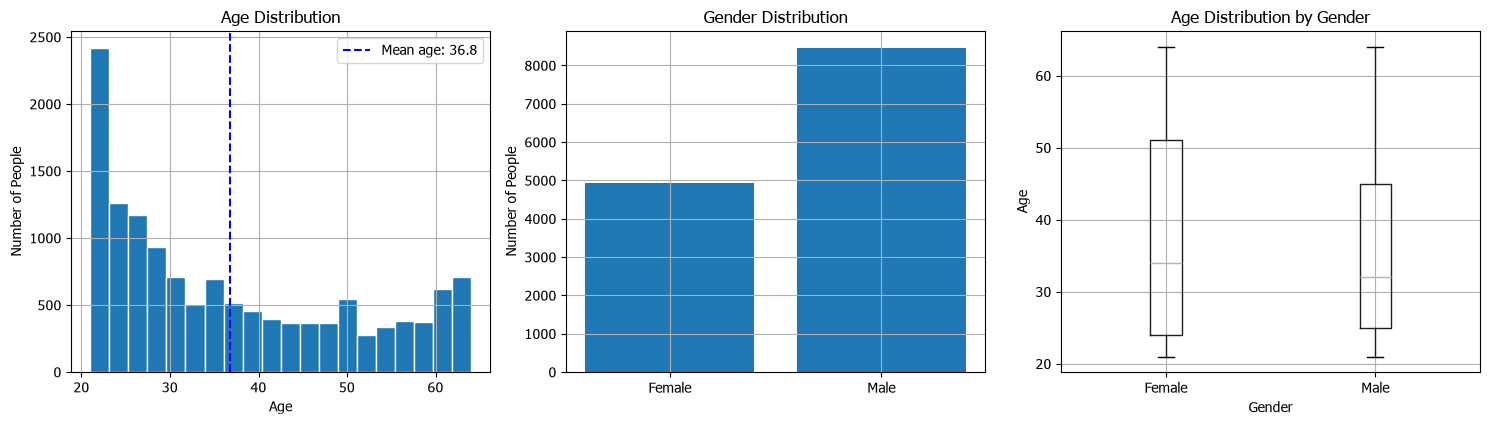

Age: 21.0 - 64.0 (Median: 32)


In [8]:
# 0.3 Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Age distribution
axes[0].hist(df['age'], bins=20, edgecolor='white')
axes[0].axvline(df['age'].mean(), linestyle='--', color='blue', label=f"Mean age: {df['age'].mean():.1f}")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of People")
axes[0].legend()

# Gender distribution
gender_counts = df['gender'].value_counts().sort_index()
axes[1].bar(["Female", "Male"], [gender_counts['F'], gender_counts['M']])
axes[1].set_title("Gender Distribution")
axes[1].set_ylabel("Number of People")

# Age by gender
df.boxplot(column='age', by='gender', ax=axes[2])
axes[2].set_xticklabels(["Female", "Male"])
axes[2].set_title("Age Distribution by Gender")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Age")

plt.suptitle("")
plt.tight_layout()
plt.show()

print(f"Age: {df['age'].min()} - {df['age'].max()} (Median: {df['age'].median():.0f})")

## 0.5 การเตรียม Features ด้วย PCA (Principal Component Analysis)

ในขั้นตอนนี้เราจะนำข้อมูลสมรรถภาพทางกายที่เป็นตัวเลขทั้ง 9 ตัวแปร (เช่น ส่วนสูง, น้ำหนัก, ความดัน ฯลฯ) มาทำการสกัดคุณลักษณะ (Feature Extraction) ด้วยเทคนิค **PCA**

เป้าหมายคือการสร้างแกนข้อมูลใหม่ (Principal Components) จากการผสมผสานตัวแปรเดิม และทำการคำนวณหาว่า **Component ใดที่มีความสัมพันธ์ (Correlation) กับ "อายุ" มากที่สุด** เพื่อนำตัวแปรนั้นไปใช้เป็นตัวแทนในการสร้างโมเดล Simple Linear Regression ใน LAB 1

In [9]:
# 0.5 การเตรียม Features: ใช้ PCA บีบอัดข้อมูลตัวเลขทั้งหมด
numerical_features = ['height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 
                      'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm']
X_pca_input = df[numerical_features].values
y_age_all = df['age'].values

N_PC = len(numerical_features)
pca = PCA(n_components=N_PC, random_state=SEED)
Z_all = pca.fit_transform(X_pca_input)

print(f"Original features: {X_pca_input.shape[1]} variables")
print(f"New features: {Z_all.shape[1]} principal components")
print(f"Explained variance: {pca.explained_variance_ratio_.sum() * 100:.1f}%\n")

# หาว่า Component ไหนสัมพันธ์กับอายุมากที่สุด
age_correlations = [np.corrcoef(Z_all[:, i], y_age_all)[0, 1] for i in range(N_PC)]
BEST_PC_AGE = np.argmax(np.abs(age_correlations))
print(f"Best component for age: PC{BEST_PC_AGE + 1} (Correlation: {age_correlations[BEST_PC_AGE]:+.3f})")

Original features: 9 variables
New features: 9 principal components
Explained variance: 100.0%

Best component for age: PC1 (Correlation: -0.431)


## LAB 1: Regression (การวิเคราะห์การถดถอย — ทำนายอายุ)

ในแลปนี้เราจะสร้างโมเดลเพื่อทำนายค่าตัวเลขต่อเนื่อง ซึ่งก็คือ **"อายุ"** โดยแบ่งการทดลองออกเป็น 2 ส่วนหลัก เพื่อให้เห็นความแตกต่างของการใช้จำนวน Features:

*   **1.1 Simple Linear Regression (ถดถอยเชิงเส้นอย่างง่าย):**
    เราจะใช้ Component ที่สกัดมาได้และมีความสัมพันธ์กับอายุมากที่สุด **เพียง 1 ตัวแปร** มาสร้างสมการเส้นตรง $\text{Age} = \beta_0 + \beta_1X$ โดยมีการคำนวณค่าสัมประสิทธิ์ ($\beta_0, \beta_1$) ด้วยสูตรคณิตศาสตร์ด้วยมือ (Manual OLS) เพื่อทำความเข้าใจการทำงานเบื้องหลัง และเทียบผลลัพธ์กับไลบรารี Scikit-learn พร้อมทั้งพล็อตตดูกราฟเส้นทแยงและจุดความคลาดเคลื่อน (Residual) 

*   **1.2 Multiple Linear Regression (ถดถอยเชิงเส้นพหุคูณ):** 
    เปลี่ยนมาใช้ Components **ทั้งหมด 9 ตัวแปรพร้อมกัน** โดยมีการแบ่งข้อมูลเป็นชุดฝึก (Train) และชุดทดสอบ (Test) จากนั้นประเมินประสิทธิภาพว่า $R^2$ เพิ่มขึ้นหรือไม่เมื่อมีตัวแปรมากขึ้น และวัดความคลาดเคลื่อนด้วยค่า **MAE** (Mean Absolute Error) เพื่อดูว่าโมเดลทำนายอายุพลาดไปโดยเฉลี่ยกี่ปี

--- Manual OLS Calculation ---
beta0 (Intercept) = 36.7751
beta1 (Slope)     = -0.1356

--- scikit-learn ---
beta0 = 36.7751
beta1 = -0.1356
R² of Simple Regression = 0.186


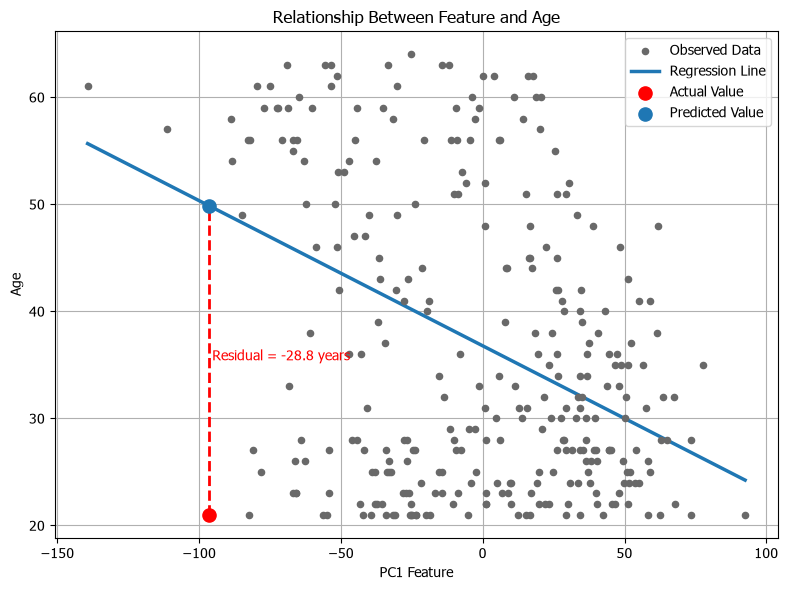


Training: 10044  Testing: 3349
R²: Simple (1 PC) = 0.186 | Multiple (9 PCs) = 0.426
MAE = 8.2 ปี  (ทำนายอายุพลาดเฉลี่ย ±8.2 ปี)


In [10]:
# LAB 1: Regression (ทำนายอายุ)

# --- 1.1 Simple Linear Regression ---
x_simple = Z_all[:, BEST_PC_AGE]
x_mean = x_simple.mean()
y_mean = y_age_all.mean()

# คำนวณสัมประสิทธิ์ด้วยสูตร OLS
beta1 = np.sum((x_simple - x_mean) * (y_age_all - y_mean)) / np.sum((x_simple - x_mean) ** 2)
beta0 = y_mean - beta1 * x_mean

print("--- Manual OLS Calculation ---")
print(f"beta0 (Intercept) = {beta0:.4f}")
print(f"beta1 (Slope)     = {beta1:.4f}")

# เทียบกับ Scikit-learn
X_simple_sk = x_simple.reshape(-1, 1)
simple_lr = LinearRegression()
simple_lr.fit(X_simple_sk, y_age_all)
y_pred_simple = simple_lr.predict(X_simple_sk)
r2_simple = r2_score(y_age_all, y_pred_simple)

print("\n--- scikit-learn ---")
print(f"beta0 = {simple_lr.intercept_:.4f}")
print(f"beta1 = {simple_lr.coef_[0]:.4f}")
print(f"R² of Simple Regression = {r2_simple:.3f}")

# Plot Simple LR (พล็อต 300 ข้อมูลแรกเพื่อให้เห็นภาพชัด)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x_simple[:300], y_age_all[:300], color='dimgray', s=20, zorder=3, label='Observed Data')
xs = np.sort(x_simple[:300])
ax.plot(xs, beta0 + beta1 * xs, color='tab:blue', lw=2.5, label='Regression Line')

y_hat_300 = beta0 + beta1 * x_simple[:300]
i = np.argmax(np.abs(y_age_all[:300] - y_hat_300))
ax.scatter(x_simple[i], y_age_all[i], color='red', s=90, zorder=4, label='Actual Value')
ax.scatter(x_simple[i], y_hat_300[i], color='tab:blue', s=90, zorder=4, label='Predicted Value')
ax.plot([x_simple[i], x_simple[i]], [y_age_all[i], y_hat_300[i]], 'r--', lw=2)
ax.annotate(f"Residual = {y_age_all[i] - y_hat_300[i]:+.1f} years",
            xy=(x_simple[i], (y_age_all[i] + y_hat_300[i]) / 2),
            xytext=(x_simple[i] + 1.0, (y_age_all[i] + y_hat_300[i]) / 2), color='red')
ax.set_xlabel(f"PC{BEST_PC_AGE + 1} Feature")
ax.set_ylabel("Age")
ax.set_title("Relationship Between Feature and Age")
ax.legend()
plt.tight_layout()
plt.show()

# --- 1.2 Multiple Linear Regression ---
Ztr, Zte, atr, ate = train_test_split(Z_all, y_age_all, test_size=0.25, random_state=SEED)
model_multi = LinearRegression()
model_multi.fit(Ztr, atr)
age_pred = model_multi.predict(Zte)
r2_multi = r2_score(ate, age_pred)

print(f"\nTraining: {len(Ztr)}  Testing: {len(Zte)}")
print(f"R²: Simple (1 PC) = {r2_simple:.3f} | Multiple ({N_PC} PCs) = {r2_multi:.3f}")

mae_multi = np.mean(np.abs(ate - age_pred))
print(f"MAE = {mae_multi:.1f} ปี  (ทำนายอายุพลาดเฉลี่ย ±{mae_multi:.1f} ปี)")

## LAB 2: Classification (การจำแนกประเภท — ทำนายเพศ)

ในแลปนี้เราจะเปลี่ยนเป้าหมายจากการทำนายตัวเลข มาเป็นการทำนาย **"หมวดหมู่ (Class)"** ซึ่งก็คือการแยกเพศชายและเพศหญิง โดยมีขั้นตอนดังนี้:

*   **2.1 Preparing Classification Data (เตรียมข้อมูล):**
    คอมพิวเตอร์ไม่สามารถคำนวณตัวอักษรได้ เราจึงต้องแปลงค่าคอลัมน์ `gender` จาก 'M' และ 'F' ให้เป็นตัวเลข `0` และ `1` (Label Encoding) และเพื่อความง่ายในการสร้างกราฟ 2 มิติ เราจะดึงข้อมูลมาใช้เพียง 2 Features คือ **ส่วนสูง (Height)** และ **น้ำหนัก (Weight)**
    
*   **2.2 Logistic Regression (สร้างโมเดลจำแนกประเภท):**
    เราเลือกใช้อัลกอริทึม Logistic Regression ซึ่งเป็นโมเดลพื้นฐานที่เหมาะสมมากสำหรับการแยกข้อมูลที่มี 2 คลาส (Binary Classification) นำมาฝึกสอนด้วยชุด Train และทำนายผลด้วยชุด Test

*   **2.3 Decision Boundary & Confusion Matrix (การสร้างภาพแสดงผลลัพธ์):**
    *   **Decision Boundary:** แสดงผลการแบ่งพื้นที่การตัดสินใจของโมเดล (พื้นที่สีฟ้าคือทายว่าชาย สีแดงคือทายว่าหญิง) โดยจุดกลมๆ คือข้อมูลจริงในชุด Test ที่นำมาพล็อตทับลงไป เพื่อดูว่าขอบเขตที่โมเดลตีเส้นขึ้นมานั้นครอบคลุมได้ถูกต้องแค่ไหน
    *   **Confusion Matrix (เมทริกซ์ความสับสน):** ตารางสรุปผลการทำนาย เพื่อให้เห็นว่าโมเดลทายถูกจริงๆ กี่คน และมีจุดที่ทายผิดพลาด (เช่น เป็นชายแต่โมเดลทายว่าเป็นหญิง) อยู่จำนวนเท่าใด

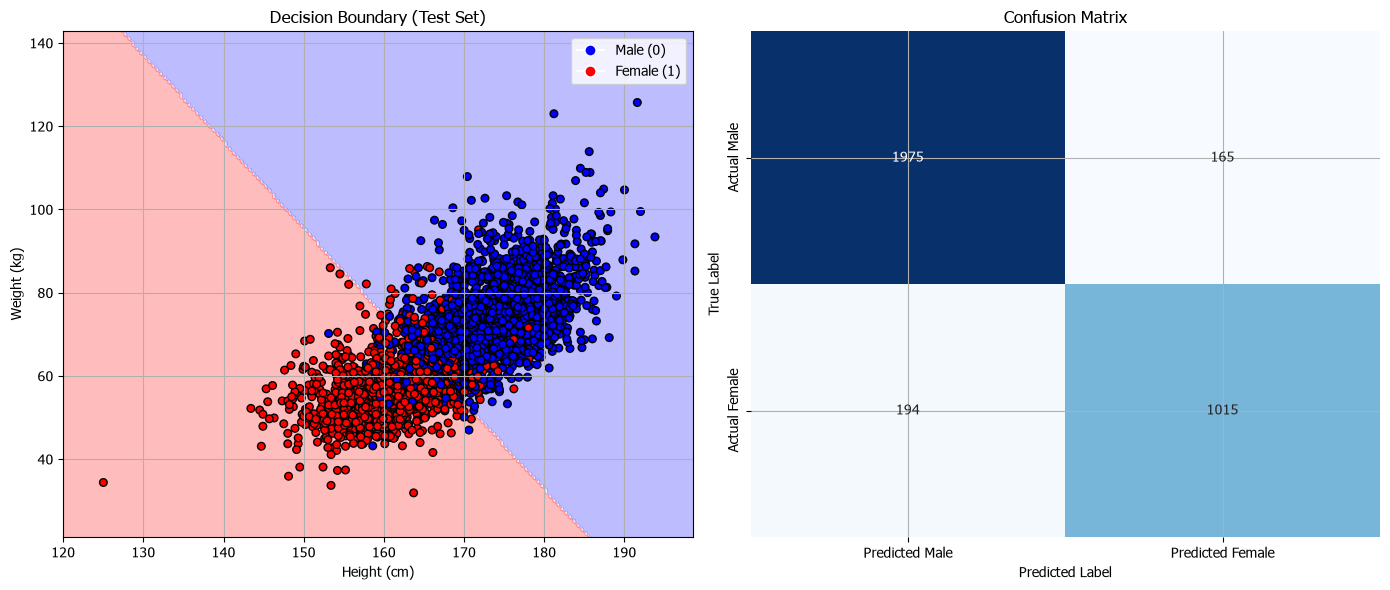

Confusion Matrix:
[[1975  165]
 [ 194 1015]]


In [11]:
# LAB 2: Classification (ทำนายเพศ)

# 2.1 Preparing Classification Data
df['gender_num'] = df['gender'].map({'M': 0, 'F': 1})

# เลือกส่วนสูงและน้ำหนัก เพื่อให้พล็อตเส้น Decision Boundary 2 มิติได้
X_class = df[['height_cm', 'weight_kg']].values
y_class = df['gender_num'].values

Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_class, y_class, test_size=0.25, random_state=SEED)

# 2.2 Logistic Regression
model_logistic = LogisticRegression()
model_logistic.fit(Xtr_c, ytr_c)
y_pred_class = model_logistic.predict(Xte_c)

# 2.3 Decision Boundary & Confusion Matrix Visualization
cm = confusion_matrix(yte_c, y_pred_class)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Decision Boundary
h_min, h_max = X_class[:, 0].min() - 5, X_class[:, 0].max() + 5
w_min, w_max = X_class[:, 1].min() - 5, X_class[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(h_min, h_max, 0.5), np.arange(w_min, w_max, 0.5))

Z = model_logistic.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
axes[0].scatter(Xte_c[:, 0], Xte_c[:, 1], c=yte_c, edgecolor='k', cmap='bwr', s=30)
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Weight (kg)')
axes[0].set_title('Decision Boundary (Test Set)')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Male (0)', markerfacecolor='blue', markersize=8),
                   Line2D([0], [0], marker='o', color='w', label='Female (1)', markerfacecolor='red', markersize=8)]
axes[0].legend(handles=legend_elements)

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['Predicted Male', 'Predicted Female'],
            yticklabels=['Actual Male', 'Actual Female'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

## LAB 3: Model Comparison (การประเมินและเปรียบเทียบโมเดล)

ในขั้นตอนนี้เราจะนำโมเดลจากทั้ง 2 LAB มาวัดประสิทธิภาพอย่างละเอียด และตรวจสอบความน่าเชื่อถือของโมเดล:

*   **Training vs Testing Performance (ตรวจสอบปัญหา Overfitting):** 
    เราสั่งให้โมเดลทำนายผลบนชุดข้อมูลที่ใช้สอน (Train) เพิ่มเติม เพื่อนำมาเทียบกับคะแนนของชุดทดสอบ (Test) หากคะแนนทั้งสองฝั่งเกาะกลุ่มใกล้เคียงกัน แสดงว่าโมเดลมีความเสถียรและสามารถนำไปใช้งานจริงกับข้อมูลใหม่ได้ (ไม่ได้เกิดจากการท่องจำข้อสอบ)

*   **Model Performance Metrics (ตัวชี้วัดประสิทธิภาพ):**
    *   **ฝั่ง Regression (ทำนายอายุ):** ประเมินด้วยค่า $R^2$ เพื่อดูว่าโมเดลอธิบายความแปรปรวนของข้อมูลได้ดีแค่ไหน และใช้ $MSE$ กับ $RMSE$ เพื่อดูค่าความคลาดเคลื่อนเฉลี่ยในการทำนายอายุ (หน่วยเป็นปี)
    *   **ฝั่ง Classification (ทำนายเพศ):** ประเมินด้วยความแม่นยำรวม ($Accuracy$) และเจาะลึกลงไปด้วยค่า $Precision$, $Recall$ และ $F1-Score$ เพื่อประเมินความสามารถในการแยกแยะแต่ละคลาสอย่างสมดุล

In [12]:
# LAB 3: Model Comparison

# ทำนายฝั่ง Train เพิ่มเติมเพื่อดูประสิทธิภาพเปรียบเทียบ
y_pred_multi_train = model_multi.predict(Ztr)
y_pred_class_train = model_logistic.predict(Xtr_c)

print("--- Regression Metrics (Age Prediction) ---")
print(f"Train R²  : {r2_score(atr, y_pred_multi_train):.3f}")
print(f"Test R²   : {r2_score(ate, age_pred):.3f}")
print(f"Test MSE  : {mean_squared_error(ate, age_pred):.3f}")
print(f"Test RMSE : {np.sqrt(mean_squared_error(ate, age_pred)):.3f}")

print("\n--- Classification Metrics (Gender Prediction) ---")
print(f"Train Accuracy: {accuracy_score(ytr_c, y_pred_class_train):.3f}")
print(f"Test Accuracy : {accuracy_score(yte_c, y_pred_class):.3f}")
print(f"Precision     : {precision_score(yte_c, y_pred_class):.3f}")
print(f"Recall        : {recall_score(yte_c, y_pred_class):.3f}")
print(f"F1-Score      : {f1_score(yte_c, y_pred_class):.3f}")

--- Regression Metrics (Age Prediction) ---
Train R²  : 0.450
Test R²   : 0.426
Test MSE  : 103.617
Test RMSE : 10.179

--- Classification Metrics (Gender Prediction) ---
Train Accuracy: 0.904
Test Accuracy : 0.893
Precision     : 0.860
Recall        : 0.840
F1-Score      : 0.850


# สรุปท้ายบท

จากข้อมูลชุดเดียว `bodyPerformance.csv` เราได้ฝึกครบทั้ง 3 LAB:

1. **LAB 1: Regression (ทำนายอายุ)** — Simple Linear Regression (1 Feature, $R^2$ ต่ำ) $\rightarrow$ Multiple Linear Regression (9 Features, $R^2$ ดีขึ้นชัดเจน) $\rightarrow$ นำโมเดลไปทำนายอายุจริงบนชุดทดสอบ
2. **LAB 2: Classification (ทำนายเพศ)** — เตรียมข้อมูล (แปลงเพศ M/F เป็น 0/1) $\rightarrow$ เห็น Decision Boundary ที่โมเดลเรียนรู้ $\rightarrow$ Logistic Regression แปลงคะแนนเชิงเส้นเป็นความน่าจะเป็น $\rightarrow$ ทำนายเพศจริง $\rightarrow$ ประเมินด้วย Confusion Matrix
3. **LAB 3: Model Comparison** — Features มากขึ้นช่วยได้แต่มีจุดอิ่มตัว | Test score สะท้อนความสามารถจริงมากกว่า Train score | ชนิดของตัวแปรเป้าหมายกำหนดว่าเป็น Regression หรือ Classification | เลือกตัวชี้วัดให้ตรงกับชนิดโจทย์

**บทเรียนจากข้อมูลจริง:** ข้อมูลจริง noisy และซ้อนทับกัน ไม่แยกสวยเหมือนตัวอย่างสังเคราะห์ | Features ที่ดีสำคัญพอ ๆ กับอัลกอริทึม | ประเมินบนข้อมูลที่โมเดลไม่เคยเห็นเสมอ

# หัวข้อต่อยอดที่ควรศึกษาเพิ่มเติม

* **Polynomial Regression** และปัญหา Overfitting เมื่อ degree สูง
* **Regularization (Ridge / Lasso)** — ควบคุม Overfitting ของโมเดลถดถอย
* **อัลกอริทึม Classification อื่น ๆ** — KNN, Decision Tree, Random Forest, SVM, Neural Network
* **ROC / Precision-Recall Curves** และการปรับ Threshold
* **Hyperparameter Tuning** — `GridSearchCV` / `RandomizedSearchCV`